In [1]:
import pandas as pd
import numpy as np

# Gerar dados para 100 registros
np.random.seed(42)  # Para garantir a reprodutibilidade

# Gerando 100 registros para cada variável
idades = np.random.randint(18, 65, size=100)
renda = np.random.randint(2000, 15000, size=100)
alturas = np.random.randint(150, 190, size=100)
pesos = np.random.randint(50, 100, size=100)
generos = np.random.choice(['Masculino', 'Feminino'], size=100)

# Criando o DataFrame
dados = pd.DataFrame({
    'Idade (anos)': idades,
    'Renda (R$)': renda,
    'Altura (cm)': alturas,
    'Peso (kg)': pesos,
    'Gênero': generos
})

# Exibir os primeiros 10 registros
dados.head(10)


,Idade (anos),Renda (R$),Altura (cm),Peso (kg),Gênero
0,56,4695,161,57,Feminino
1,46,11687,188,56,Masculino
2,32,7258,151,52,Masculino
3,60,7618,152,66,Feminino
4,25,8736,186,82,Masculino
5,38,2391,166,97,Masculino
6,56,14706,151,61,Feminino
7,36,14666,151,71,Masculino
8,40,7892,177,71,Feminino
9,28,5561,172,95,Masculino


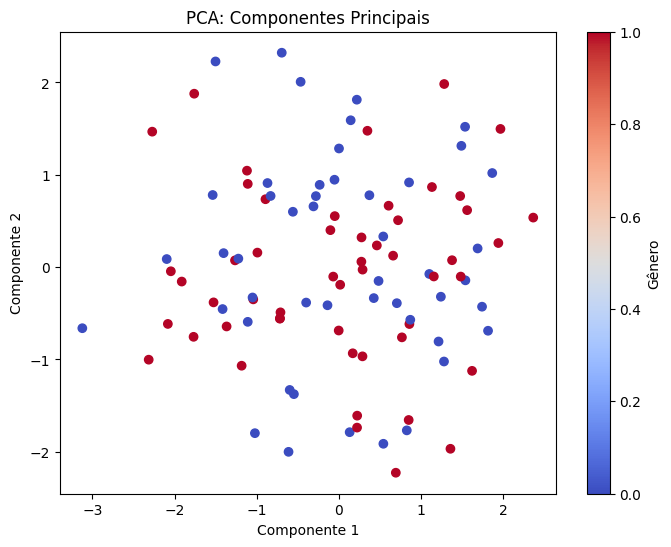

   Componente 1  Componente 2
0     -2.081854     -0.615444
1     -0.279554      0.768804
2     -1.536160      0.780798
3     -2.045396     -0.045216
4      1.540579     -0.143436
Proporção da variação explicada por cada componente:
[0.34818595 0.2635068 ]

Variação total explicada pelos dois primeiros componentes:
0.6116927497617494


In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Selecionando apenas as variáveis numéricas para a PCA
dados_numericos = dados[['Idade (anos)', 'Renda (R$)', 'Altura (cm)', 'Peso (kg)']]

# Normalizando os dados para a PCA (importante para a técnica)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(dados_numericos)

# Aplicando PCA para reduzir as variáveis para 2 componentes principais
pca = PCA(n_components=2)
dados_pca = pca.fit_transform(dados_normalizados)

# Criando um DataFrame com as 2 componentes principais
dados_pca_df = pd.DataFrame(dados_pca, columns=['Componente 1', 'Componente 2'])

# Visualizando o gráfico dos 2 componentes principais
plt.figure(figsize=(8,6))
plt.scatter(dados_pca_df['Componente 1'], dados_pca_df['Componente 2'], c=dados['Gênero'].apply(lambda x: 0 if x == 'Masculino' else 1), cmap='coolwarm')
plt.title('PCA: Componentes Principais')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.colorbar(label='Gênero')
plt.show()

# Exibindo os resultados dos componentes principais
print(dados_pca_df.head())

# Exibindo a proporção da variação explicada por cada componente principal
print("Proporção da variação explicada por cada componente:")
print(pca.explained_variance_ratio_)

# Exibindo a variação total explicada pelos dois primeiros componentes
print("\nVariação total explicada pelos dois primeiros componentes:")
print(np.sum(pca.explained_variance_ratio_))



[1 0]


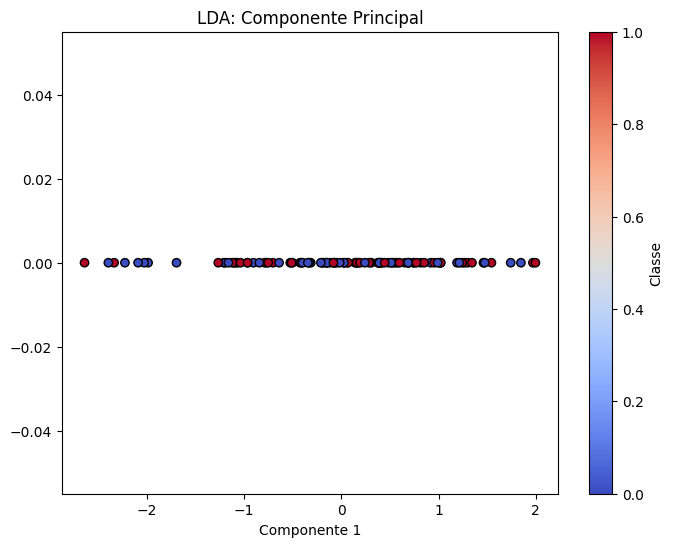

   Componente 1
0      0.028084
1      0.918280
2     -1.984375
3      0.060610
4     -0.068745

Proporção da variação explicada pelo componente:
[1.]

Variação total explicada pelo componente:
1.0


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt



# Criar a coluna 'Classe' com valores binários baseados no gênero
dados['Classe'] = dados['Gênero'].apply(lambda x: 0 if x == 'Masculino' else 1)

# Verifique se a coluna 'Classe' tem exatamente 2 classes
print(dados['Classe'].unique())

# Selecionando as variáveis numéricas para a LDA
dados_numericos = dados[['Idade (anos)', 'Renda (R$)', 'Altura (cm)', 'Peso (kg)']]
dados_classe = dados['Classe']

# Normalizando os dados para a LDA
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(dados_numericos)

# Aplicando LDA para reduzir as variáveis para 1 componente principal
lda = LinearDiscriminantAnalysis(n_components=1)
dados_lda = lda.fit_transform(dados_normalizados, dados_classe)

# Criando um DataFrame com o componente principal da LDA
dados_lda_df = pd.DataFrame(dados_lda, columns=['Componente 1'])

# Visualizando o gráfico do componente principal com as classes coloridas
plt.figure(figsize=(8,6))
plt.scatter(dados_lda_df['Componente 1'], np.zeros_like(dados_lda_df['Componente 1']),
            c=dados['Classe'], cmap='coolwarm', edgecolors='k')
plt.title('LDA: Componente Principal')
plt.xlabel('Componente 1')
plt.colorbar(label='Classe')
plt.show()

# Exibindo os resultados dos componentes principais
print(dados_lda_df.head())

# Exibindo a proporção da variação explicada pelo componente
print("\nProporção da variação explicada pelo componente:")
print(lda.explained_variance_ratio_)

# Exibindo a variação total explicada pelo componente
print("\nVariação total explicada pelo componente:")
print(np.sum(lda.explained_variance_ratio_))


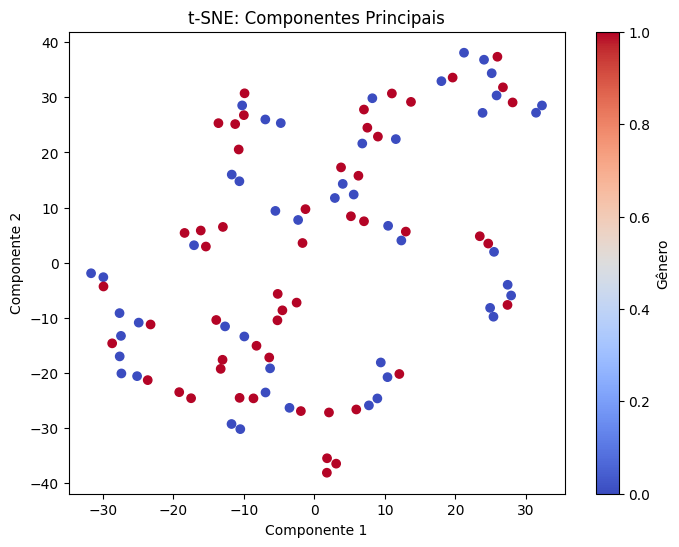

   Componente 1  Componente 2
0      9.010012     22.871010
1    -10.493079    -30.182919
2     18.008299     32.926624
3     -9.887159     30.723122
4    -25.118797    -20.574154


In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Selecionando as variáveis numéricas para o t-SNE
dados_numericos = dados[['Idade (anos)', 'Renda (R$)', 'Altura (cm)', 'Peso (kg)']]

# Normalizando os dados para o t-SNE
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(dados_numericos)

# Aplicando t-SNE para reduzir as variáveis para 2 componentes principais
tsne = TSNE(n_components=2, perplexity=5, random_state=42)  # Ajustando a perplexidade para 5
dados_tsne = tsne.fit_transform(dados_normalizados)

# Criando um DataFrame com os componentes principais do t-SNE
dados_tsne_df = pd.DataFrame(dados_tsne, columns=['Componente 1', 'Componente 2'])

# Visualizando o gráfico dos 2 componentes principais do t-SNE
plt.figure(figsize=(8,6))
plt.scatter(dados_tsne_df['Componente 1'], dados_tsne_df['Componente 2'], c=dados['Gênero'].apply(lambda x: 0 if x == 'Masculino' else 1), cmap='coolwarm')
plt.title('t-SNE: Componentes Principais')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.colorbar(label='Gênero')
plt.show()

# Exibindo os resultados dos componentes principais
print(dados_tsne_df.head())

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")
